## libraries

In [1]:
import os
import pandas as pd
import librosa
import numpy as np
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split

## 1. load data

In [2]:
root_dir = "/kaggle/input/missing-fundamental-puzzle/kaggle_dataset-20251026T143755Z-1-001/"

train = pd.read_csv(f"{root_dir}/kaggle_dataset/train.csv")
test = pd.read_csv(f"{root_dir}/kaggle_dataset/test.csv")
submission = pd.read_csv(f"{root_dir}/kaggle_dataset/sample_submission.csv")

In [3]:
train.head(3)

,Pitch_ID,Path
0,52,kaggle_dataset/train/sample_0.wav
1,64,kaggle_dataset/train/sample_1.wav
2,6,kaggle_dataset/train/sample_2.wav


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Pitch_ID', ylabel='Count'>

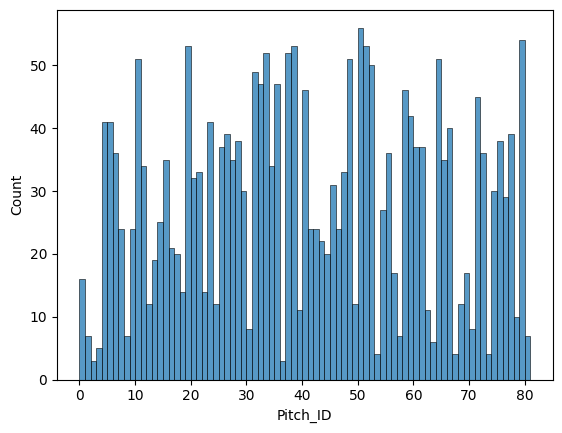

In [4]:
import seaborn as sns
sns.histplot(train['Pitch_ID'], bins=81)

## 2. create dataset

In [5]:
df_train, df_valid = train_test_split(train, test_size=0.2, random_state=42)
df_train.reset_index(inplace=True, drop=True)
df_valid.reset_index(inplace=True, drop=True)

print(df_train.shape)
print(df_valid.shape)

(1864, 2)
(466, 2)


In [6]:
SR = 16000
DURATION = 10  # seconds
TARGET_LEN = int(SR * DURATION)
mx_len = 0
X_train = []
for idx in tqdm(range(len(df_train))):
    path_to_wav = os.path.join(root_dir, df_train.loc[idx, 'Path'])
    wav, sr = librosa.load(path_to_wav, sr=SR, mono=True)
    mx_len = max(mx_len, len(wav))
    if len(wav) > TARGET_LEN:
        wav = wav[:TARGET_LEN]
    else:
        wav = np.pad(wav, (0, TARGET_LEN - len(wav)))
    X_train.append(wav)

X_train = np.array(X_train)
y_train = df_train['Pitch_ID'].values

  0%|          | 0/1864 [00:00<?, ?it/s]

In [7]:
# SR = 16000
# DURATION = 3  # seconds
# TARGET_LEN = int(SR * DURATION)

X_valid = []
for idx in tqdm(range(len(df_valid))):
    path_to_wav = os.path.join(root_dir, df_valid.loc[idx, 'Path'])
    wav, sr = librosa.load(path_to_wav, sr=SR, mono=True)
    if len(wav) > TARGET_LEN:
        wav = wav[:TARGET_LEN]
    else:
        wav = np.pad(wav, (0, TARGET_LEN - len(wav)))
    X_valid.append(wav)

X_valid = np.array(X_valid)
y_valid = df_valid['Pitch_ID'].values

  0%|          | 0/466 [00:00<?, ?it/s]

In [8]:
# --- Load test ---
X_test = []
for idx in tqdm(range(len(test))):
    path_to_wav = os.path.join(root_dir, test.loc[idx, 'Path'])
    wav, sr = librosa.load(path_to_wav, sr=SR, mono=True)
    if len(wav) > TARGET_LEN:
        wav = wav[:TARGET_LEN]
    else:
        wav = np.pad(wav, (0, TARGET_LEN - len(wav)))
    X_test.append(wav)

X_test = np.array(X_test)

  0%|          | 0/583 [00:00<?, ?it/s]

## 3. create model

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

# Глобальные параметры из вашего кода
# SR = 16000
# DURATION = 3
# TARGET_LEN = int(SR * DURATION)
# Предполагаем, что X_train (np.array) и y_train (np.array) уже загружены.

# Параметры Мел-спектрограммы
N_MELS = 128
N_FFT = 2048 # Размер окна FFT
HOP_LENGTH = 512
NUM_CLASSES = len(np.unique(y_train)) # Количество уникальных классов

# Кодирование меток (из np.array в LongTensor)
le = LabelEncoder()
y_encoded = le.fit_transform(y_train)
y_tensors = torch.from_numpy(y_encoded).long()

## 🛠️ Создание PyTorch Dataset
class AudioSpectrogramDataset(Dataset):
    def __init__(self, X_data, y_labels, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH):
        self.X_data = X_data
        self.y_labels = y_labels
        
        # Трансформация torchaudio для Мел-спектрограммы
        self.melspectrogram = torchaudio.transforms.MelSpectrogram(
            sample_rate=sr,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels
        )

    def __len__(self):
        return len(self.X_data)

    def __getitem__(self, idx):
        # 1. Загрузка/Получение волновой формы
        # X_data уже является numpy-массивом (waveform), преобразуем его в Tensor
        waveform_np = self.X_data[idx]
        # PyTorch ожидает float32
        waveform = torch.from_numpy(waveform_np).float().unsqueeze(0) # Добавляем dimension для канала (mono)

        # 2. Преобразование в Мел-спектрограмму
        melspec = self.melspectrogram(waveform)
        
        # 3. Преобразование в дБ и нормализация
        melspec_db = torchaudio.transforms.AmplitudeToDB()(melspec)
        
        # Стандартная нормализация по всему датасету (для простоты здесь используем простой Min-Max,
        # в реальном проекте лучше использовать среднее и стандартное отклонение всего X_train_spec)
        min_val = melspec_db.min()
        max_val = melspec_db.max()
        if max_val > min_val:
            melspec_db = (melspec_db - min_val) / (max_val - min_val)
            
        # ResNet для изображений ожидает [C, H, W]. melspec_db уже [1, N_MELS, T]
        
        label = self.y_labels[idx]
        return melspec_db, label

# Разделение данных для PyTorch
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_tensors.numpy(), test_size=0.2, random_state=42, stratify=y_encoded
)
y_train_split = torch.from_numpy(y_train_split).long()
y_val_split = torch.from_numpy(y_val_split).long()

# Создание экземпляров Dataset и DataLoader
train_dataset = AudioSpectrogramDataset(X_train_split, y_train_split)
val_dataset = AudioSpectrogramDataset(X_val_split, y_val_split)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

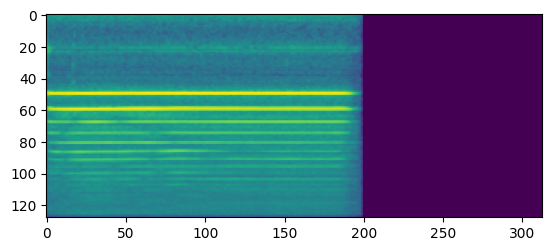

In [10]:
import matplotlib.pyplot as plt
plt.imshow(train_dataset[0][0][0])

In [11]:
## 🏗️ Создание Модели ResNet
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        
        # Основной путь
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Skip-connection (сокращение)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        # Добавление skip-connection
        out += self.shortcut(x) 
        out = self.relu(out)
        return out

class ResNetAudio(nn.Module):
    def __init__(self, block, num_blocks, num_classes=NUM_CLASSES):
        super(ResNetAudio, self).__init__()
        self.in_channels = 64
        
        # Начальный слой (приспособленный для спектрограмм 128xT)
        self.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        
        # MaxPool часто опускают или используют меньший размер для сохранения временного разрешения
        # self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1) 
        
        # ResNet слои
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2) # Уменьшение размера
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2) # Уменьшение размера
        
        # Финальный слой
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1)) # Global Average Pooling
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride_ in strides:
            layers.append(block(self.in_channels, out_channels, stride_))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        # out = self.maxpool(out) # Если используется
        
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1) # Flatten
        out = self.fc(out)
        return out

# Создание экземпляра модели (аналог ResNet-18, но с меньшим числом слоев)
def ResNetAudio10():
    return ResNetAudio(BasicBlock, [1, 1, 1])
def ResNetAudio34():
    return ResNetAudio(BasicBlock, [3, 4, 6, 3])

In [12]:
import torch.nn as nn

class Bottleneck(nn.Module):
    # Коэффициент расширения
    expansion = 4 

    def __init__(self, in_channels, out_channels, stride=1):
        super(Bottleneck, self).__init__()
        
        # 1x1 свёртка для уменьшения размерности (бутылочное горлышко)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # 3x3 свёртка (основная)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # 1x1 свёртка для восстановления размерности
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        
        self.relu = nn.ReLU(inplace=True)
        
        # Skip-connection (сокращение)
        self.shortcut = nn.Sequential()
        
        # Условие для изменения размерности: либо stride != 1 (пространственное сжатие), 
        # либо in_channels != out_channels * expansion (изменение числа каналов)
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        # 1x1 -> ReLU
        out = self.relu(self.bn1(self.conv1(x)))
        # 3x3 (с возможным сжатием по stride) -> ReLU
        out = self.relu(self.bn2(self.conv2(out)))
        # 1x1 (восстановление каналов)
        out = self.bn3(self.conv3(out))
        
        # Добавление skip-connection
        out += self.shortcut(x) 
        out = self.relu(out)
        return out

# Предполагаем, что NUM_CLASSES определен где-то выше
# from torch import nn # Если не импортирован

class ResNetAudio(nn.Module):
    def __init__(self, block, num_blocks, num_classes):
        super(ResNetAudio, self).__init__()
        # Инициализируем in_channels для первого слоя
        self.in_channels = 64 
        self.block_expansion = block.expansion
        
        # Начальный слой (приспособлен для спектрограмм 1xTxF или 1x128xT)
        self.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        
        # MaxPool часто опускают или используют меньший размер для сохранения временного разрешения
        # self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # ResNet слои: [64, 128, 256, 512] - это промежуточные каналы (out_channels в Bottleneck)
        # Фактическое число выходных каналов будет: [256, 512, 1024, 2048]
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2) 
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2) 
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2) # Добавление 4-го слоя
        
        # Финальный слой
        # Фактическое число каналов после layer4 равно 512 * expansion
        final_channels = 512 * self.block_expansion
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1)) # Global Average Pooling
        self.fc = nn.Linear(final_channels, num_classes)

        # Инициализация весов (полезно для более глубоких сетей)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        # Первый блок в слое может сжимать пространственный размер (stride > 1) 
        # и/или изменять число каналов.
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride_ in strides:
            layers.append(block(self.in_channels, out_channels, stride_))
            # Обновляем in_channels для следующего блока в этом слое
            self.in_channels = out_channels * self.block_expansion 
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        # out = self.maxpool(out) # Если используется
        
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out) # Вызов 4-го слоя
        
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1) # Flatten
        out = self.fc(out)
        return out

# Создание экземпляра модели ResNet-50
# Предполагаем, что NUM_CLASSES определено.
def ResNetAudio50(num_classes=NUM_CLASSES):
    # Используем Bottleneck и конфигурацию слоев [3, 4, 6, 3]
    return ResNetAudio(Bottleneck, [3, 4, 6, 3], num_classes)
model = ResNetAudio50()

In [13]:
## 🧠 Обучение Модели

# Установка устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-4)

# Количество эпох
NUM_EPOCHS = 100
best_val_loss = float('inf')
patience = 10
patience_counter = 0

print(f"\nНачало обучения ResNet на {device}...")
for epoch in range(NUM_EPOCHS):
    # --- Режим Обучения ---
    model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Train"):
        inputs, labels = inputs.to(device), labels.to(device)

        # Обнуление градиентов
        optimizer.zero_grad()

        # Прямой проход
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Обратный проход и оптимизация
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    train_loss = running_loss / len(train_dataset)
    
    # --- Режим Валидации ---
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} Val"):
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_dataset)
    val_accuracy = 100 * correct / total
    
    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], '
          f'Train Loss: {train_loss:.4f}, '
          f'Val Loss: {val_loss:.4f}, '
          f'Val Acc: {val_accuracy:.2f}%')

    # --- Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Сохранение лучшей модели
        torch.save(model.state_dict(), 'best_audio_resnet.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print("\nОбучение завершено. Лучшая модель сохранена как 'best_audio_resnet.pth'.")


Начало обучения ResNet на cuda...


Epoch 1 Val: 100%|██████████| 12/12 [00:02<00:00,  5.30it/s]


Epoch [1/100], Train Loss: 4.1095, Val Loss: 4.8525, Val Acc: 0.54%


Epoch 2 Val: 100%|██████████| 12/12 [00:02<00:00,  5.65it/s]


Epoch [2/100], Train Loss: 2.0760, Val Loss: 2.0835, Val Acc: 50.40%


...

Epoch [59/100], Train Loss: 0.0002, Val Loss: 0.0727, Val Acc: 97.86%


Epoch 60 Val: 100%|██████████| 12/12 [00:02<00:00,  5.67it/s]


Epoch [60/100], Train Loss: 0.0001, Val Loss: 0.0764, Val Acc: 97.59%


Epoch 61 Val: 100%|██████████| 12/12 [00:02<00:00,  5.67it/s]

Epoch [61/100], Train Loss: 0.0002, Val Loss: 0.0734, Val Acc: 97.86%
Early stopping at epoch 61

Обучение завершено. Лучшая модель сохранена как 'best_audio_resnet.pth'.


In [14]:
model = ResNetAudio50().to(device)
model.load_state_dict(torch.load('best_audio_resnet.pth'))

<All keys matched successfully>

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm

# --- 1. Параметры и Загрузка Данных ---

# Предполагаем, что эти параметры соответствуют параметрам обучения
# SR = 16000
# N_MELS = 128
# N_FFT = 2048
# HOP_LENGTH = 512
# NUM_CLASSES = len(le.classes_) # Используем LabelEncoder, обученный на y_train

# Предполагаем, что X_test (numpy array) уже загружен
# и le (LabelEncoder) уже обучен/доступен.

# --- 2. Подготовка Тестового DataLoader ---

# Используем ранее определенный класс AudioSpectrogramDataset
# Для теста метки не нужны, но класс их требует. Передадим фиктивные метки.
y_test_dummy = np.zeros(len(X_test), dtype=int) 
y_test_dummy_tensor = torch.from_numpy(y_test_dummy).long()

test_dataset = AudioSpectrogramDataset(X_test, y_test_dummy_tensor)
TEST_BATCH_SIZE = 32 # Можно использовать больший батч, так как градиенты не считаются
test_loader = DataLoader(test_dataset, batch_size=TEST_BATCH_SIZE, shuffle=False, num_workers=4)

# --- 3. Загрузка Модели ---

# Определение устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Пересоздаем ту же архитектуру модели ResNet-18
# def ResNetAudio18():
#     # BasicBlock должен быть определен, как в коде обучения
#     # Здесь используется структура [2, 2, 2, 2] и 512 каналов на выходе FC
#     return ResNetAudio(BasicBlock, [2, 2, 2, 2], num_classes=NUM_CLASSES)

# model = ResNetAudio18().to(device)

# # Загрузка сохраненных весов
# try:
#     model.load_state_dict(torch.load('best_audio_resnet.pth', map_location=device))
#     print("✅ Веса модели 'best_audio_resnet.pth' успешно загружены.")
# except FileNotFoundError:
#     print("⚠️ Файл весов 'best_audio_resnet.pth' не найден. Проверьте путь.")
#     # Для целей демонстрации можно пропустить инференс, если веса не найдены
#     exit()

# --- 4. Инференс ---

model.eval() # ❗ Перевод модели в режим инференса (отключает BatchNorm и Dropout)
all_predictions = []

print("\nНачало предсказаний на тестовом наборе...")
with torch.no_grad(): # ❗ Отключаем вычисление градиентов для экономии памяти
    for inputs, _ in tqdm(test_loader, desc="Инференс"):
        inputs = inputs.to(device)
        
        # Прямой проход
        outputs = model(inputs)
        
        # Получение предсказанного класса (индекс с максимальным значением)
        _, predicted = torch.max(outputs.data, 1)
        
        # Сохранение предсказаний
        all_predictions.extend(predicted.cpu().numpy())

# --- 5. Декодирование и Результаты ---

# Преобразование числовых ID обратно в исходные метки классов
predicted_class_ids = np.array(all_predictions)
predicted_class_names = le.inverse_transform(predicted_class_ids)

print("\n--- Результаты Инференса ---")
print(f"Общее количество предсказаний: {len(predicted_class_names)}")
print("Пример первых 10 предсказанных классов:")
print(predicted_class_names[:10])


Начало предсказаний на тестовом наборе...


Инференс: 100%|██████████| 19/19 [00:03<00:00,  6.28it/s]


--- Результаты Инференса ---
Общее количество предсказаний: 583
Пример первых 10 предсказанных классов:
[77 69 16 43 38 64 59 61 33 71]


## 6. create submission file

In [16]:
submission['Pitch_ID'] = predicted_class_names

In [17]:
submission

,Path,Pitch_ID
0,kaggle_dataset/test/sample_0.wav,77
1,kaggle_dataset/test/sample_1.wav,69
2,kaggle_dataset/test/sample_2.wav,16
3,kaggle_dataset/test/sample_3.wav,43
4,kaggle_dataset/test/sample_4.wav,38
...,...,...
578,kaggle_dataset/test/sample_578.wav,64
579,kaggle_dataset/test/sample_579.wav,64
580,kaggle_dataset/test/sample_580.wav,7
581,kaggle_dataset/test/sample_581.wav,1


In [18]:
submission.to_csv("base_resnet50_10sec.csv", index=False)